# Analise SINAN: Ilheus e Itabuna (2014-2024)


In [1]:
from IPython.display import display
import matplotlib.pyplot as plt
import pandas as pd

from sinan_pipeline import (
    AGRAVO_LABELS,
    AGRAVOS_ALVO,
    ANOS_ALVO,
    CITY_CODES,
    DATA_DIR,
    PARQUET_DIR,
    audit_downloads,
    build_city_counts,
    build_expected_file_map,
    build_rankings,
    plot_rankings,
    repair_downloads,
)

pd.set_option("display.max_rows", 20)
pd.set_option("display.max_columns", None)
plt.style.use("seaborn-v0_8-whitegrid")

expected_total_files = len(AGRAVOS_ALVO) * len(ANOS_ALVO)
print(f"Agravos no escopo: {len(AGRAVOS_ALVO)}")
print(f"Anos no escopo: {ANOS_ALVO[0]} a {ANOS_ALVO[-1]}")
print(f"Arquivos esperados no escopo: {expected_total_files}")
print(f"Diretorio de CSV: {DATA_DIR.resolve()}")
print(f"Diretorio de parquet: {PARQUET_DIR.resolve()}")
print(f"Cidades analisadas: {CITY_CODES}")

Agravos no escopo: 28
Anos no escopo: 2014 a 2024
Arquivos esperados no escopo: 308
Diretorio de CSV: /home/solana/ic/Dados
Diretorio de parquet: /home/solana/pysus
Cidades analisadas: {'Ilheus': 291360, 'Itabuna': 291480}


## 1. Auditoria do download

In [2]:
sinan_db, expected_file_map = build_expected_file_map(AGRAVOS_ALVO, ANOS_ALVO, catalog_timeout_seconds=5.0)

download_audit_df = audit_downloads(expected_file_map, DATA_DIR, PARQUET_DIR)
audit_summary_df = (
    download_audit_df.groupby(["status", "needs_download", "needs_reconvert"], as_index=False)
    .size()
    .rename(columns={"size": "arquivos"})
    .sort_values(["needs_download", "needs_reconvert", "status"], ascending=[False, False, True])
    .reset_index(drop=True)
)

display(audit_summary_df)

audit_pendencias_df = download_audit_df.loc[
    download_audit_df["needs_download"] | download_audit_df["needs_reconvert"],
    [
        "agravo",
        "agravo_nome",
        "ano",
        "status",
        "needs_download",
        "needs_reconvert",
        "csv_state",
        "parquet_state",
        "csv_path",
        "parquet_path",
    ],
].reset_index(drop=True)

if audit_pendencias_df.empty:
    print("Nenhuma pendencia encontrada. O download ja esta completo para o escopo selecionado.")
else:
    display(audit_pendencias_df)

,status,needs_download,needs_reconvert,arquivos
0,empty,True,False,1
1,empty,False,False,7
2,present,False,False,300


,agravo,agravo_nome,ano,status,needs_download,needs_reconvert,csv_state,parquet_state,csv_path,parquet_path
0,PEST,Peste,2021,empty,True,False,empty,missing,Dados/PESTBR21.csv,/home/solana/pysus/PESTBR21.parquet


## 2. Correcao incremental

In [3]:
repair_result = repair_downloads(
    sinan_db,
    expected_file_map,
    download_audit_df,
    DATA_DIR,
    PARQUET_DIR,
    download_timeout_seconds=5.0,
)

if repair_result["downloaded_stems"]:
    print(f"Arquivos baixados nesta etapa: {len(repair_result['downloaded_stems'])}")
    display(pd.DataFrame({"stem": repair_result["downloaded_stems"]}))
else:
    print("Download incremental em modo no-op: nenhum arquivo precisou ser baixado.")

if not repair_result["download_errors_df"].empty:
    print("Alguns downloads falharam e permanecem pendentes para nova tentativa.")
    display(repair_result["download_errors_df"])

if repair_result["converted_stems"]:
    print(f"Arquivos convertidos para CSV nesta etapa: {len(repair_result['converted_stems'])}")
    display(pd.DataFrame({"stem": repair_result["converted_stems"]}))
else:
    print("Conversao em modo no-op: nenhum parquet precisou ser convertido.")

if not repair_result["conversion_errors_df"].empty:
    display(repair_result["conversion_errors_df"])

download_audit_df = audit_downloads(expected_file_map, DATA_DIR, PARQUET_DIR)
audit_summary_df = (
    download_audit_df.groupby(["status", "needs_download", "needs_reconvert"], as_index=False)
    .size()
    .rename(columns={"size": "arquivos"})
    .sort_values(["needs_download", "needs_reconvert", "status"], ascending=[False, False, True])
    .reset_index(drop=True)
)
display(audit_summary_df)

audit_vazios_df = download_audit_df.loc[
    download_audit_df["status"] == "empty",
    ["agravo", "agravo_nome", "ano", "status", "csv_state", "parquet_state"],
].reset_index(drop=True)
if not audit_vazios_df.empty:
    print("Arquivos classificados como vazios entram no ranking com zero notificacoes.")
    display(audit_vazios_df)

audit_pendencias_df = download_audit_df.loc[
    download_audit_df["needs_download"] | download_audit_df["needs_reconvert"],
    [
        "agravo",
        "agravo_nome",
        "ano",
        "status",
        "needs_download",
        "needs_reconvert",
        "csv_state",
        "parquet_state",
    ],
].reset_index(drop=True)

if audit_pendencias_df.empty:
    print("Nenhuma pendencia restante apos a auditoria e a correcao incremental.")
else:
    print("Ainda existem pendencias locais. Elas ficarao fora da contagem ate serem resolvidas.")
    display(audit_pendencias_df)

PESTBR21.parquet:   0%|          | 0.00/9.93 [00:00<?, ?B/s]      /home/solana/ic/.venv/lib/python3.12/site-packages/tqdm/std.py:533: TqdmWarning: clamping frac to range [0, 1]
  full_bar = Bar(frac,
PESTBR21.parquet: 100%|██████████| 9.93/9.93 [00:00<00:00, 2.83kB/s]

Download incremental em modo no-op: nenhum arquivo precisou ser baixado.
Alguns downloads falharam e permanecem pendentes para nova tentativa.


,stem,error
0,PESTBR21,TypeError: 'ParquetSet' object is not iterable


Arquivos convertidos para CSV nesta etapa: 1


,stem
0,PESTBR21


,status,needs_download,needs_reconvert,arquivos
0,empty,False,False,8
1,present,False,False,300


Arquivos classificados como vazios entram no ranking com zero notificacoes.


,agravo,agravo_nome,ano,status,csv_state,parquet_state
0,PEST,Peste,2020,empty,empty,empty
1,PEST,Peste,2021,empty,empty,empty
2,PEST,Peste,2023,empty,empty,empty
3,TETN,Tetano Neonatal,2015,empty,empty,empty
4,TETN,Tetano Neonatal,2018,empty,empty,empty
5,TETN,Tetano Neonatal,2019,empty,empty,empty
6,TETN,Tetano Neonatal,2020,empty,empty,empty
7,TETN,Tetano Neonatal,2021,empty,empty,empty


Nenhuma pendencia restante apos a auditoria e a correcao incremental.


## 3. Base analitica por cidade

In [4]:
city_counts_df, skipped_files_df = build_city_counts(download_audit_df, CITY_CODES, DATA_DIR, AGRAVO_LABELS)
serie_anual_df = city_counts_df.copy()

ranking_ilheus_df, ranking_itabuna_df, ranking_geral_df = build_rankings(city_counts_df)

print(f"Linhas em city_counts_df: {len(city_counts_df)}")
print(f"Linhas em serie_anual_df: {len(serie_anual_df)}")

resumo_cidades_df = (
    serie_anual_df.groupby(["agravo", "agravo_nome", "cidade"], as_index=False)["casos"]
    .sum()
    .pivot(index=["agravo", "agravo_nome"], columns="cidade", values="casos")
    .fillna(0)
)
resumo_cidades_df["Total"] = resumo_cidades_df.sum(axis=1)
display(resumo_cidades_df.sort_values("Total", ascending=False).head(15))

if not skipped_files_df.empty:
    print("Arquivos ignorados na contagem por falta de base local resolvida ou coluna municipal.")
    display(skipped_files_df)

Linhas em city_counts_df: 616
Linhas em serie_anual_df: 616


,cidade,Ilheus,Itabuna,Total
agravo,agravo_nome,,,
TUBE,Tuberculose,1489,1762,3251
SIFA,Sifilis Adquirida,714,1495,2209
SIFG,Sifilis em Gestante,564,605,1169
VARC,Varicela,534,511,1045
HANS,Hanseniase,173,422,595
SIFC,Sifilis Congenita,316,116,432
LTAN,Leishmaniose Tegumentar Americana,251,60,311
LEPT,Leptospirose,148,163,311
MENI,Meningite,83,117,200


## 4. Top 10 e validacoes

In [5]:
assert len(expected_file_map) == expected_total_files
assert (city_counts_df["casos"] <= city_counts_df["linhas_arquivo"]).all()
assert ranking_ilheus_df["casos"].is_monotonic_decreasing
assert ranking_itabuna_df["casos"].is_monotonic_decreasing
assert ranking_geral_df["casos"].is_monotonic_decreasing
assert set(city_counts_df.loc[city_counts_df["agravo"] == "TRAC", "cidade_coluna"].unique()) == {"ID_MUNI_RE"}
assert set(city_counts_df.loc[city_counts_df["agravo"] == "NTRA", "cidade_coluna"].unique()) == {"ID_MUNICIP"}
print("Validacoes basicas concluidas com sucesso.")

print("Top 10 - Ilheus")
display(ranking_ilheus_df)

print("Top 10 - Itabuna")
display(ranking_itabuna_df)

print("Top 10 - Consolidado")
display(ranking_geral_df)

Validacoes basicas concluidas com sucesso.
Top 10 - Ilheus


,posicao,agravo,agravo_nome,casos,agravo_exibicao
0,1,TUBE,Tuberculose,1489,Tuberculose (TUBE)
1,2,SIFA,Sifilis Adquirida,714,Sifilis Adquirida (SIFA)
2,3,SIFG,Sifilis em Gestante,564,Sifilis em Gestante (SIFG)
3,4,VARC,Varicela,534,Varicela (VARC)
4,5,SIFC,Sifilis Congenita,316,Sifilis Congenita (SIFC)
5,6,LTAN,Leishmaniose Tegumentar Americana,251,Leishmaniose Tegumentar Americana (LTAN)
6,7,HANS,Hanseniase,173,Hanseniase (HANS)
7,8,LEPT,Leptospirose,148,Leptospirose (LEPT)
8,9,MENI,Meningite,83,Meningite (MENI)
9,10,CHAG,Doenca de Chagas Aguda,61,Doenca de Chagas Aguda (CHAG)


Top 10 - Itabuna


,posicao,agravo,agravo_nome,casos,agravo_exibicao
0,1,TUBE,Tuberculose,1762,Tuberculose (TUBE)
1,2,SIFA,Sifilis Adquirida,1495,Sifilis Adquirida (SIFA)
2,3,SIFG,Sifilis em Gestante,605,Sifilis em Gestante (SIFG)
3,4,VARC,Varicela,511,Varicela (VARC)
4,5,HANS,Hanseniase,422,Hanseniase (HANS)
5,6,LEPT,Leptospirose,163,Leptospirose (LEPT)
6,7,MENI,Meningite,117,Meningite (MENI)
7,8,SIFC,Sifilis Congenita,116,Sifilis Congenita (SIFC)
8,9,LTAN,Leishmaniose Tegumentar Americana,60,Leishmaniose Tegumentar Americana (LTAN)
9,10,COQU,Coqueluche,42,Coqueluche (COQU)


Top 10 - Consolidado


,posicao,agravo,agravo_nome,casos,agravo_exibicao
0,1,TUBE,Tuberculose,3251,Tuberculose (TUBE)
1,2,SIFA,Sifilis Adquirida,2209,Sifilis Adquirida (SIFA)
2,3,SIFG,Sifilis em Gestante,1169,Sifilis em Gestante (SIFG)
3,4,VARC,Varicela,1045,Varicela (VARC)
4,5,HANS,Hanseniase,595,Hanseniase (HANS)
5,6,SIFC,Sifilis Congenita,432,Sifilis Congenita (SIFC)
6,7,LTAN,Leishmaniose Tegumentar Americana,311,Leishmaniose Tegumentar Americana (LTAN)
7,8,LEPT,Leptospirose,311,Leptospirose (LEPT)
8,9,MENI,Meningite,200,Meningite (MENI)
9,10,CHAG,Doenca de Chagas Aguda,61,Doenca de Chagas Aguda (CHAG)


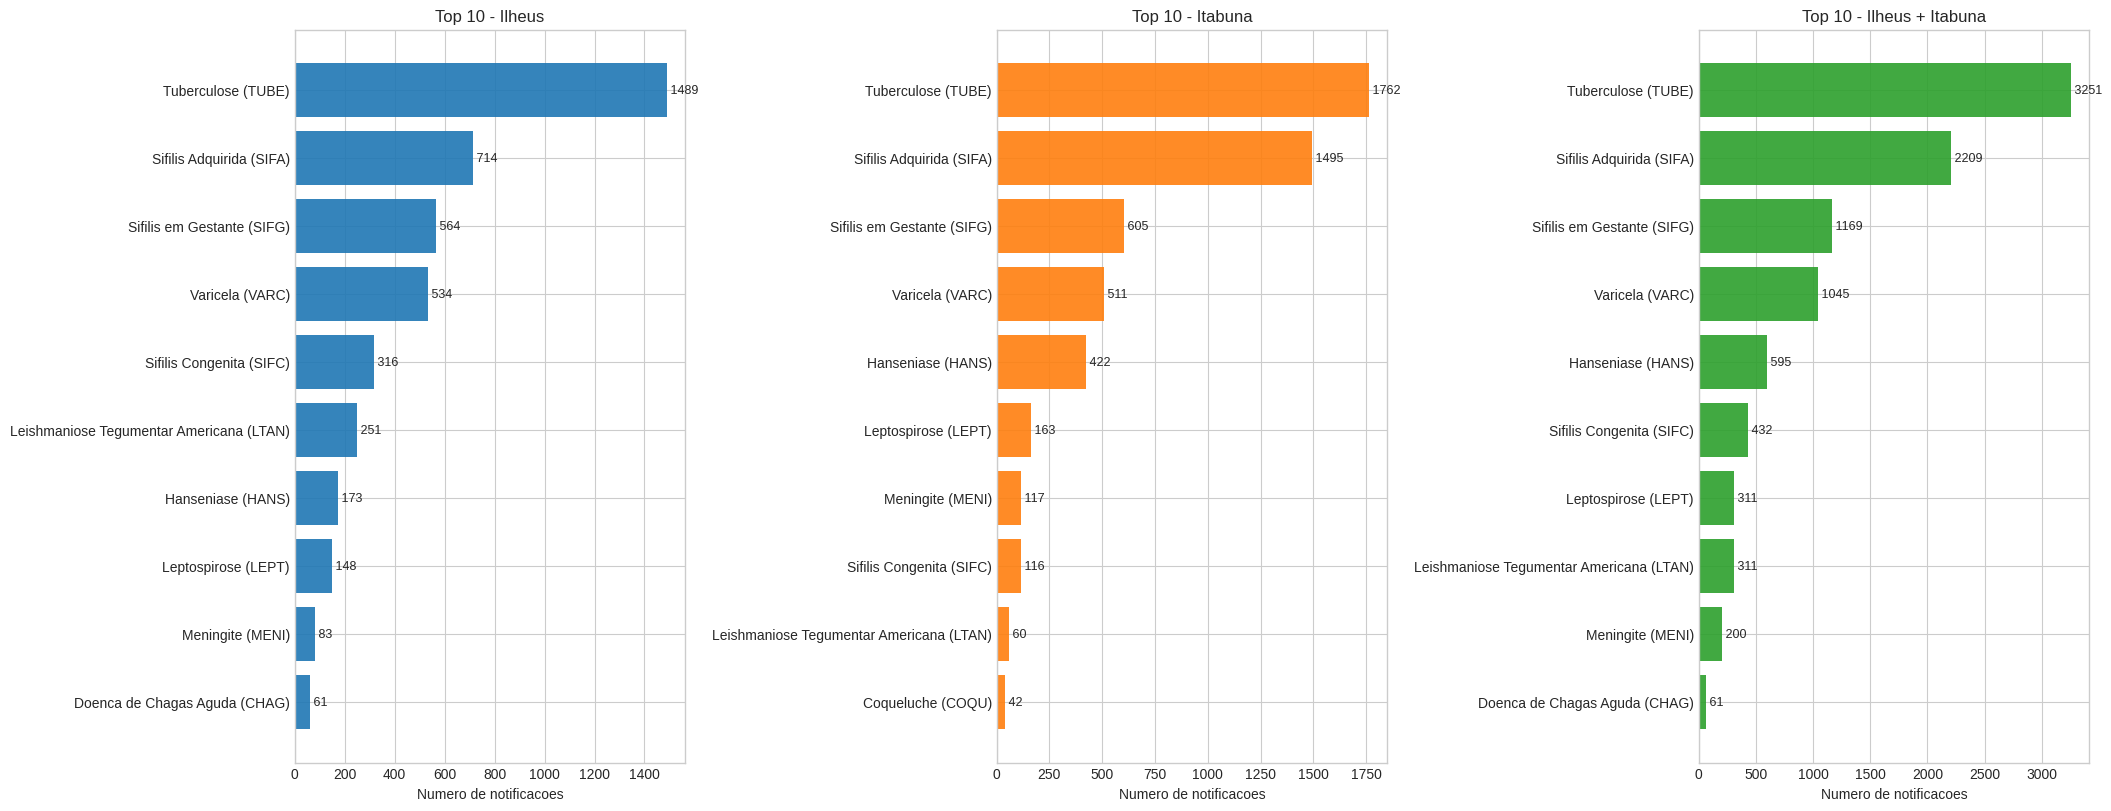

In [6]:
fig, axes = plot_rankings(ranking_ilheus_df, ranking_itabuna_df, ranking_geral_df)
plt.show()